# Ejercicios de práctica
En el siguiente notebook, se busca resolver de manera simple los desafís propuestos para la clase 2, indicados en el archivo "Ejercicios.md".

## Primera parte
Usando el dataset `winequality-red.csv`, el cual consiste en datos de vinos rojos basados en datos físico-químicos y 
una métrica de calidad de vino, (más info en [Kaggle](https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009)) 
Queremos predecir la calidad del vino usando los atributos físico-químicos del mismo.

### Ejercicio 1
Lea el dataset como un DataFrame de Pandas. Realice un estudio de variables. Cómo se llaman y qué están midiendo exactamente (vea la documentación del dataset). Además, analice qué tipo de variables (incluido el target) son, cuál es el rango de estas variables y cómo se distribuyen (histograma). Además, realice una matriz de correlación, ¿cuáles variables parecen estar correlacionadas? ¿Y con respecto a la calidad del vino?

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [6]:
df = pd.read_csv('datasets/winequality-red.csv')

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [7]:
print("\nTamaño del dataset: ", df.shape)

print("\nInformación del dataset: ")
print(df.info())

print("\nEstadísticas descriptivas del dataset: ")
print(df.describe())


Tamaño del dataset:  (1599, 12)

Información del dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None

Estadísticas descriptivas del dataset: 
       fixed acidity

In [55]:
# Determinación de los rangos de los features según mediciones
df.max() - df.min()

fixed acidity            11.30000
volatile acidity          1.46000
citric acid               1.00000
residual sugar           14.60000
chlorides                 0.59900
free sulfur dioxide      71.00000
total sulfur dioxide    283.00000
density                   0.01362
pH                        1.27000
sulphates                 1.67000
alcohol                   6.50000
quality                   5.00000
dtype: float64

Los features parecen ser todos variables numéricas continuas, sin valores nulos, mientras que el target "quality" sería un entero entre 0 a 10.

In [25]:
def plot_histograma(data, column, ax, bins=15, kde=False, mvd=False, snk=False):
    skewness = (data[column].skew())
    kurtosis = (data[column].kurt())
    media = (data[column].mean())
    var = (data[column].var())
    std = (data[column].std())

    plt.grid(axis='y')
    sns.histplot(data[column], bins=bins, kde=kde, ax=ax)

    if snk:
        ax.text(0.65, 0.8, f'Asimetría: {skewness:.2f}', transform=ax.transAxes, fontsize=10, color='blue')
        ax.text(0.65, 0.73, f'Curtosis: {kurtosis:.2f}', transform=ax.transAxes, fontsize=10, color='blue')
    ax.axvline(media, color='red', linestyle='--', label='Media')
    if mvd:
        ax.text(0.10, 0.8, f'Media: {media:.2f}', transform=ax.transAxes, fontsize=10, color='red')
        ax.text(0.10, 0.73, f'Var: {var:.2f}', transform=ax.transAxes, fontsize=10, color='red')
        ax.text(0.10, 0.66, f'Std: {std:.2f}', transform=ax.transAxes, fontsize=10, color='red')

    # ax.set_title(f'Variable {column}')
    ax.set_xlabel(f'{column}')
    ax.set_ylabel('Frecuencia')
    # plt.show()
    # return

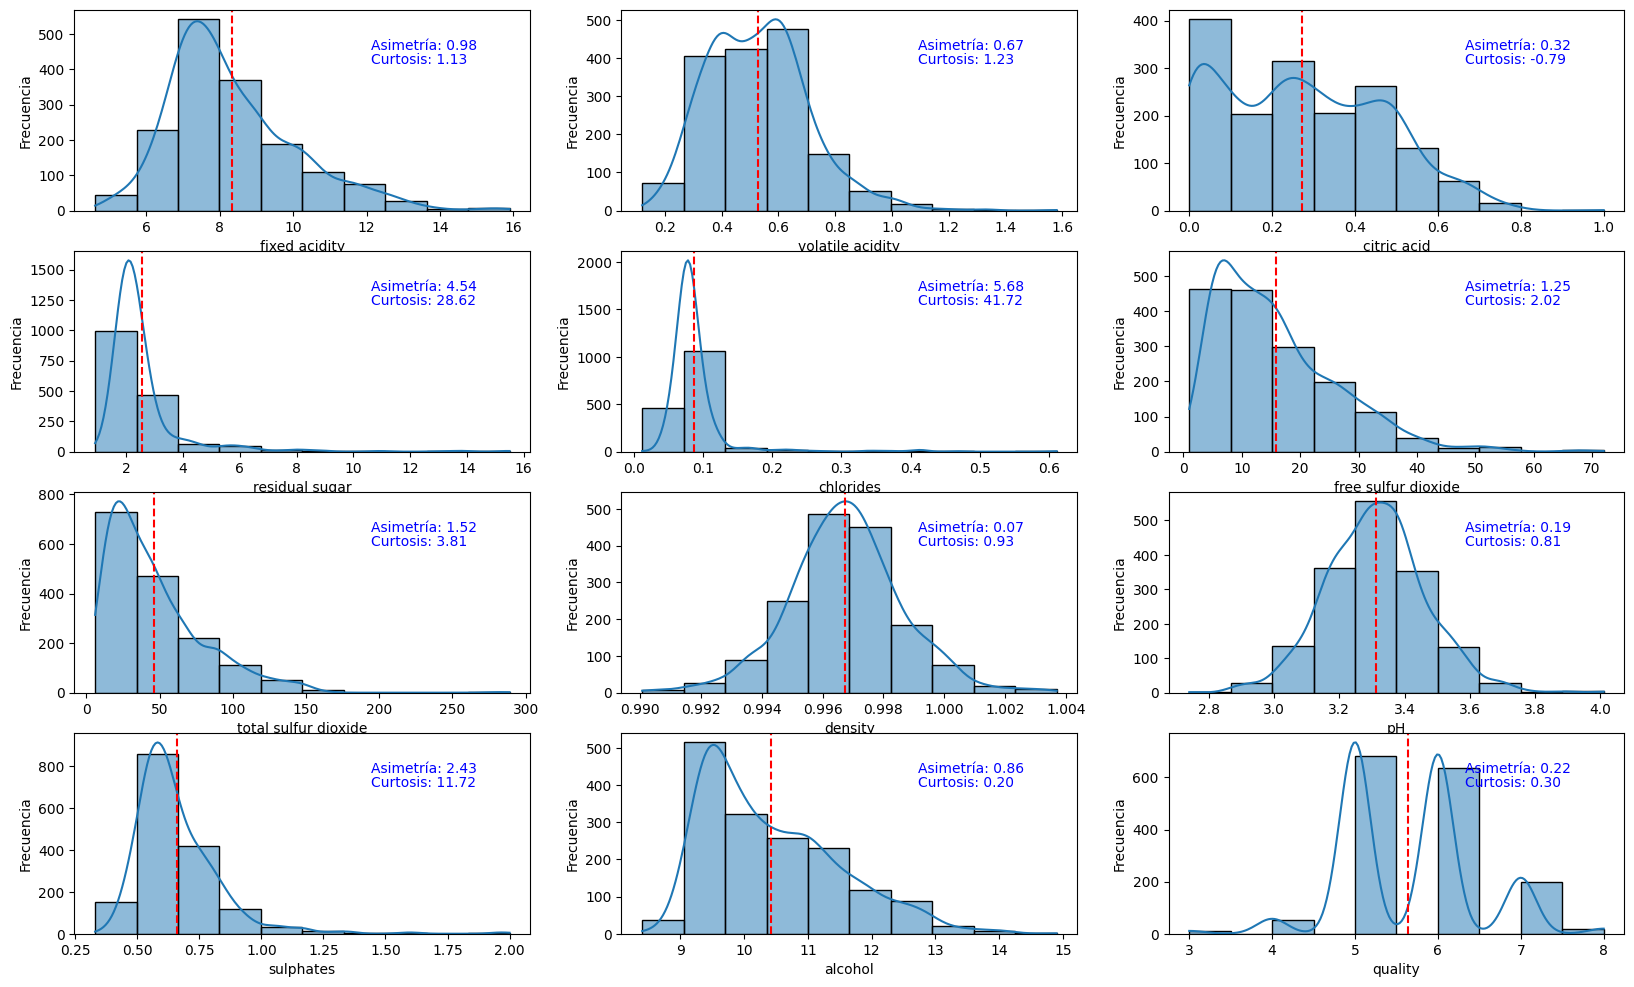

In [37]:
n_fig = len(df.columns)
a = 4
b = math.ceil(n_fig / a)

fig, axes = plt.subplots(a, b, figsize=(5 * a, 4 * b))
axes = axes.flatten()
for i, col in enumerate(df.columns):
    plot_histograma(df, col, ax=axes[i], kde=True, snk=True, bins=10)


Text(0.65, 0.73, 'Curtosis: 0.30')

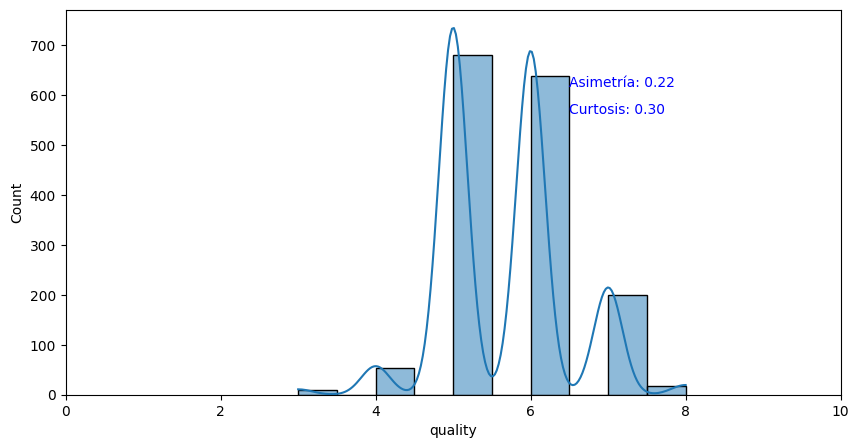

In [54]:

# Se plotea nuevamente, por separado la distribución del target.
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['quality'], bins=10, kde=True, ax=ax)
ax.set_xlim(0,10)

skewness = (df['quality'].skew())
kurtosis = (df['quality'].kurt())
ax.text(0.65, 0.8, f'Asimetría: {skewness:.2f}', transform=ax.transAxes, fontsize=10, color='blue')
ax.text(0.65, 0.73, f'Curtosis: {kurtosis:.2f}', transform=ax.transAxes, fontsize=10, color='blue')



#### Correlación

<Axes: >

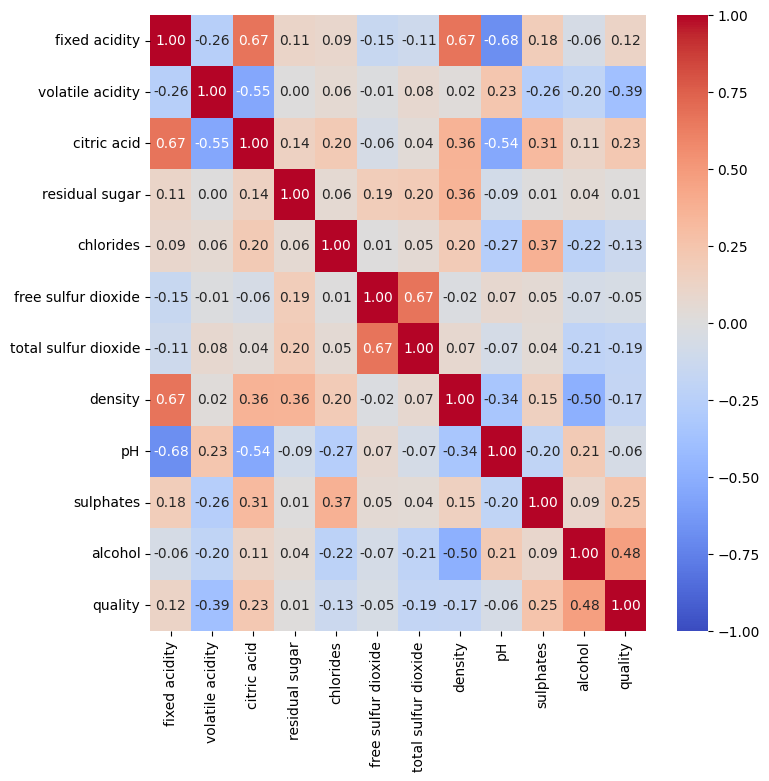

In [83]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f", 
    cmap='coolwarm',
    center=0, 
    vmin=-1, 
    vmax=1,
    ax=ax
)
# sns.heatmap(
#     df.corr(method='spearman'),
#     annot=True,
#     fmt=".2f", 
#     cmap='coolwarm',
#     center=0, 
#     vmin=-1, 
#     vmax=1,
#     ax=ax[1]
# )
# sns.heatmap(
#     df.corr(method='kendall'),
#     annot=True,
#     fmt=".2f", 
#     cmap='coolwarm',
#     center=0, 
#     vmin=-1, 
#     vmax=1,
#     ax=ax[2]
# )

#### Análisis de outliers

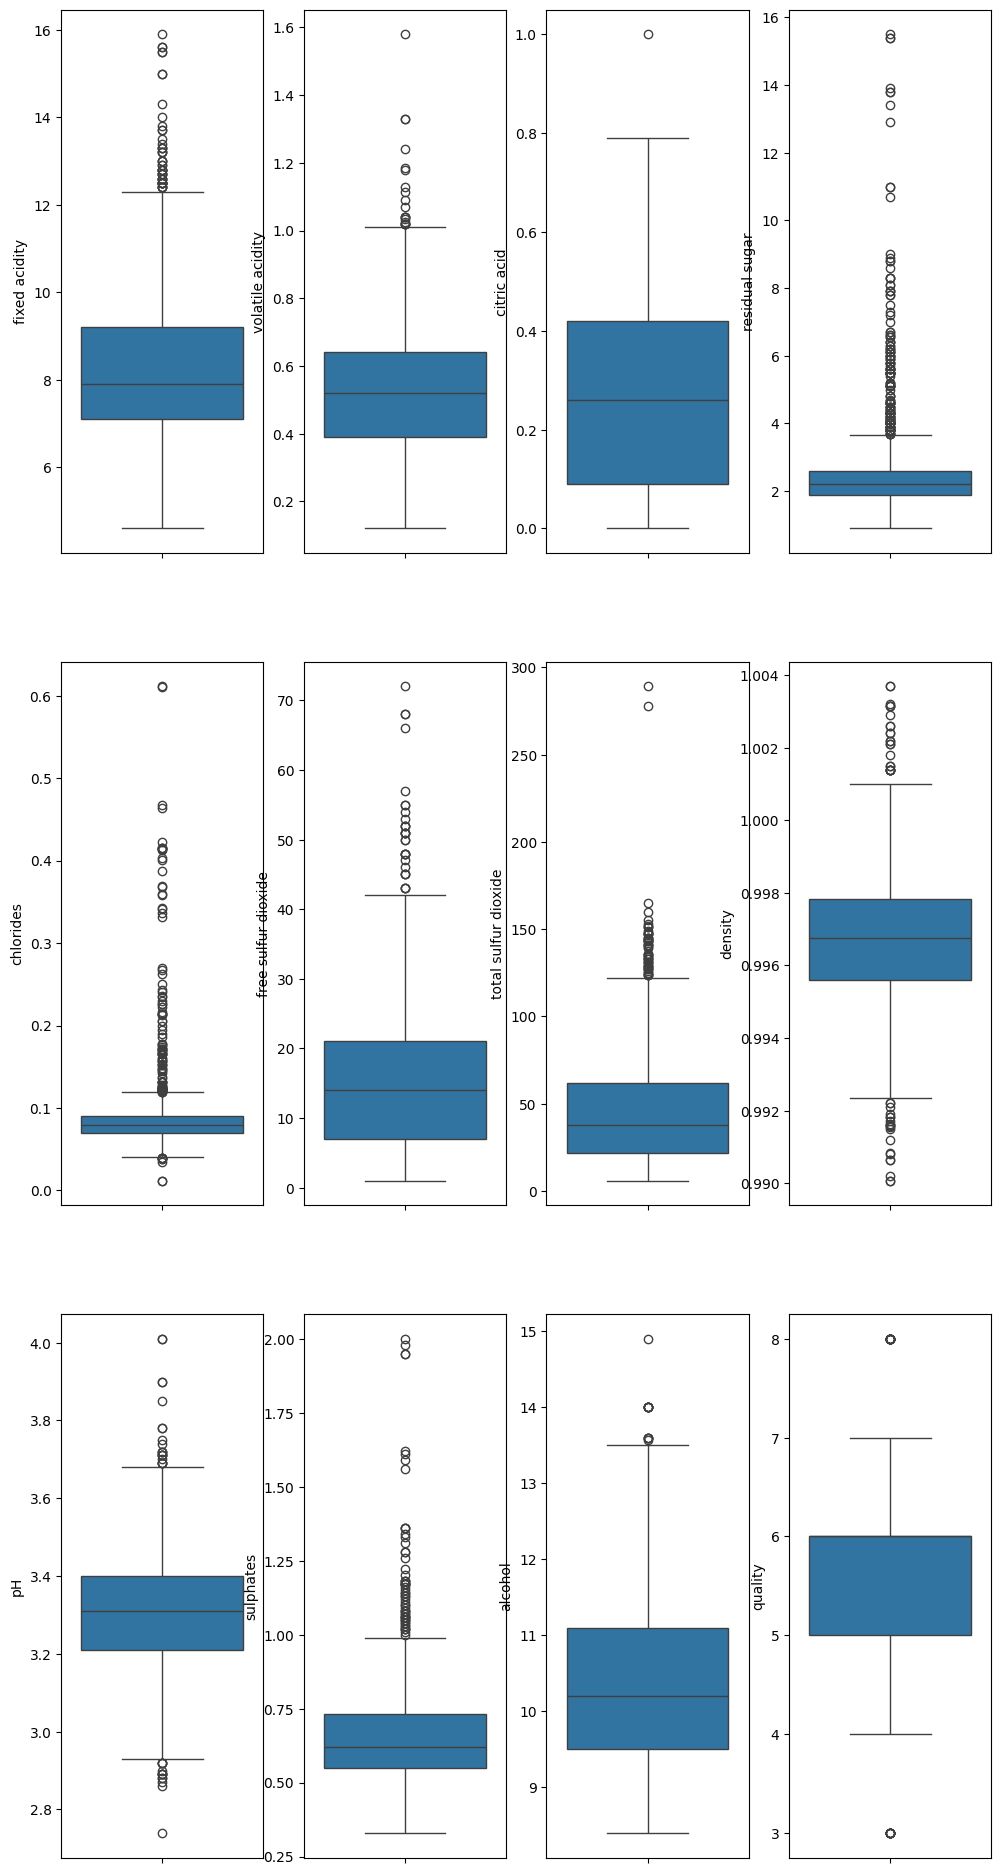

In [86]:
n_fig = len(df.columns)
a = 3
b = math.ceil(n_fig / a)

fig, axes = plt.subplots(a, b, figsize=(4 * a, 6 * b))
axes = axes.flatten()
for i, col in enumerate(df.columns):
    sns.boxplot(y=df[col], ax=axes[i])

### Ejercicio 2
Realice si es necesaria la limpieza de datos y corrección de errores.

In [87]:
df.duplicated().sum()

np.int64(240)

In [90]:
df.drop_duplicates(inplace=True)
df.shape

(1359, 12)

### Ejercicio 3
Construya usando un SVM un modelo de regresión o clasificación multi-clase (según lo que considere más apropiado) en el que se intente predecir la calidad del vino usando el nivel de alcohol.
1. Realiza la separación entre el dataset de entrenamiento y testeo. Utilice 80 % - 20 %.
2. Determine qué métrica se va a usar para evaluar la calidad del modelo (MSE, MAE, etc.)
3. Entrene el modelo con el set de entrenamiento.
4. Evalúe el modelo con la métrica de evaluación.

In [104]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error,
                            mean_squared_error,
                            mean_absolute_percentage_error,
                            r2_score)
from sklearn.svm import SVR

In [94]:
X = df.drop('quality', axis=1)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [97]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
svm = SVR()
grid = GridSearchCV(
    svm,
    [
        {"C": [0.01, 0.1, 0.5, 1, 5, 10, 50], "kernel": ["linear"]},
        {"C": [0.01, 0.1, 0.5, 1, 5, 10, 50], "gamma": [0.01, 0.02, 0.1, 0.5, 1, 2, 5, 10] , "kernel": ["rbf", "sigmoid"]},
        {"C": [0.01, 0.1, 0.5, 1, 5, 10, 50], "degree": [2, 3, 4, 5, 6] , "kernel": ["poly"]},
    ],
    refit=True,
    cv=5,
    scoring='neg_mean_absolute_error'
)
grid.fit(X_train, y_train)

,estimator,SVR()
,param_grid,"[{'C': [0.01, 0.1, ...], 'gamma': [0.01, 0.02, ...], 'kernel': ['rbf', 'sigmoid']}]"
,scoring,'neg_mean_absolute_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,kernel,'rbf'


In [111]:
grid.best_params_

{'C': 0.5, 'gamma': 0.1, 'kernel': 'rbf'}

In [113]:
y_pred = grid.predict(X_test)

In [114]:
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE de testeo fue: {mae}")
print(f"RMSE de testeo fue: {rmse}")
print(f"MAPE de testeo fue: {mape}")
print(f"R2 de testeo fue: {r2}")

MAE de testeo fue: 0.46543629424204036
RMSE de testeo fue: 0.39049904618424247
MAPE de testeo fue: 0.08940103240040954
R2 de testeo fue: 0.4487247613315971


In [115]:
# Comparando con un Ridge
from sklearn.linear_model import Ridge

ridge_hitters = Ridge()

grid = GridSearchCV(ridge_hitters,
                    {"alpha": np.linspace(0, 20, 1000)},
                    refit=True,
                    cv=5,
                    scoring='neg_mean_absolute_error')
grid.fit(X_train,y_train)

ridge_hitters = grid.best_estimator_
y_pred_r = ridge_hitters.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_r)
rmse = mean_squared_error(y_test, y_pred_r)
mape = mean_absolute_percentage_error(y_test, y_pred_r)
r2 = r2_score(y_test, y_pred_r)

print(f"MAE de testeo fue: {mae}")
print(f"RMSE de testeo fue: {rmse}")
print(f"MAPE de testeo fue: {mape}")
print(f"R2 de testeo fue: {r2}")

MAE de testeo fue: 0.5037490190152529
RMSE de testeo fue: 0.42922586523124456
MAPE de testeo fue: 0.09667740020034786
R2 de testeo fue: 0.39405334376574896


## Segunda parte
Continuando con el ejercicio de la clase 2 del dataset `UCI_Credit_Card.csv`. Incorpore al estudio de los modelos al menos un SVM de clasificación y repita las evaluaciones que se hicieron con los clasificadores. Discuta los resultados obtenidos.